In [32]:
import os
import shutil

if not os.path.exists('/content'):
    !mkdir -p /content

if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

%cd /content
!GIT_LFS_SKIP_SMUDGE=1 git clone -b Vic https://github.com/SihamDaanouni/InstantMesh.git

!pip install git+https://github.com/CompVis/taming-transformers.git


%cd /content/InstantMesh

/content
Cloning into 'InstantMesh'...
remote: Enumerating objects: 399, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 399 (delta 161), reused 111 (delta 109), pack-reused 168 (from 2)
Receiving objects: 100% (399/399), 42.95 MiB | 35.87 MiB/s, done.
Resolving deltas: 100% (169/169), done.
  Cloning https://github.com/CompVis/taming-transformers.git to /tmp/pip-req-build-bh46fpry
  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git /tmp/pip-req-build-bh46fpry
^C
ERROR: Operation cancelled by user
/content/InstantMesh


In [33]:
import os
import shutil


if not os.path.exists('/content'):
    !mkdir -p /content


%cd /content
if os.path.exists('/content/SyncDreamer'):
    shutil.rmtree('/content/SyncDreamer')
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/liuyuan-pal/SyncDreamer


!pip install -q git+https://github.com/CompVis/taming-transformers.git

!pip install -r "/content/SyncDreamer/requirements.txt"

!pip install -q "numpy<2.0.0"
!pip install -q onnxruntime-gpu ninja
!pip install -q PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg]

!pip install -q pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

os.environ['CUDA_HOME'] = '/usr/local/cuda'

os.environ['PATH'] = os.environ.get('PATH', '') + ':/usr/local/cuda/bin'


%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install -q --no-build-isolation .


!pip install -q "cupy-cuda12x<14.0.0"
!pip install -q peft==0.10.0

%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE ===")
print("Branche active :", end=" ")
!git branch --show-current

/content
Cloning into 'SyncDreamer'...
remote: Enumerating objects: 405, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 405 (delta 48), reused 32 (delta 31), pack-reused 341 (from 1)
Receiving objects: 100% (405/405), 83.54 MiB | 48.11 MiB/s, done.
Resolving deltas: 100% (112/112), done.
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/NVlabs/tiny-cuda-nn/ to /tmp/pip-req-build-i6w_mh92
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/tiny-cuda-nn/ /tmp/pip-req-build-i6w_mh92
  Resolved https://github.com/NVlabs/tiny-cuda-nn/ to commit 749dd70c5afc5a9dadb85e5652ed65d55e0ba187
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-tgl3_dwq
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-tgl3_dwq


In [34]:

!pip install -q gdown
import gdown
import urllib.request
import os
import requests

output_dir = "/content/InstantMesh/ckpt"
os.makedirs(output_dir, exist_ok=True)


SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
output_sync = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")


SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
SYNCDREAM_KAGGLE = "https://huggingface.co/camenduru/SyncDreamer/resolve/main/syncdreamer-pretrain.ckpt"
output = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")
response = requests.get(SYNCDREAM_KAGGLE, stream=True)
response.raise_for_status()

with open(output, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

VITL14_URL = "https://openaipublic.azureedge.net/clip/models/b8cca3fd41ae0c99ba7e8951adf17d267cdb84cd88be6f7c2e0eca1737a03836/ViT-L-14.pt"
output_vit = os.path.join(output_dir, "ViT-L-14.pt")

if not os.path.exists(output_vit):
    urllib.request.urlretrieve(VITL14_URL, output_vit)

print(f"Vérification : {os.listdir(output_dir)}")

Vérification : ['ViT-L-14.pt', 'syncdreamer-pretrain.ckpt']


In [35]:
import sys
import site
from importlib import reload

sys.path.append('/usr/local/lib/python3.12/dist-packages')
sys.path.append('/content/SyncDreamer')

In [36]:
import os
import shutil

target_dir = "/content/SyncDreamer/ckpt"
os.makedirs(target_dir, exist_ok=True)

source_dir = "/content/InstantMesh/ckpt"

if os.path.exists(source_dir):
    for file in os.listdir(source_dir):
        shutil.move(os.path.join(source_dir, file), os.path.join(target_dir, file))
    print(f"Fichiers déplacés vers {target_dir}")
else:
    print("Le dossier source n'a pas été trouvé. Vérification manuelle...")

if os.path.exists(os.path.join(target_dir, "syncdreamer-pretrain.ckpt")):
    print("SUCCÈS : syncdreamer-pretrain.ckpt est au bon endroit !")
else:
    print("ERREUR : Le fichier est toujours introuvable. Relance la cellule de téléchargement.")

!ln -s /content/SyncDreamer/ckpt /content/InstantMesh/ckpt 2>/dev/null

Fichiers déplacés vers /content/SyncDreamer/ckpt
SUCCÈS : syncdreamer-pretrain.ckpt est au bon endroit !


In [37]:
!pip install taming-transformers-rom1504

In [38]:
!pip uninstall -y clip
!pip install git+https://github.com/openai/CLIP.git

Found existing installation: clip 1.0
Uninstalling clip-1.0:
  Successfully uninstalled clip-1.0
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ghwq7gtj
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ghwq7gtj
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d563137fe97da6d9f49fe242dd2af367b791b62c56ec452a06bc9e8f24082a55
  Stored in directory: /tmp/pip-ephem-wheel-cache-l7obpkhd/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [39]:
!pip install transformers==4.44.2 

In [40]:
!pip install peft==0.17.0

  Using cached peft-0.17.0-py3-none-any.whl.metadata (14 kB)
Using cached peft-0.17.0-py3-none-any.whl (503 kB)
  Attempting uninstall: peft
    Found existing installation: peft 0.10.0
    Uninstalling peft-0.10.0:
      Successfully uninstalled peft-0.10.0


In [41]:
def executer_inference_3d(filename="/content/InstantMesh/examples/hatsune_miku.png", model_type="zero123plus_finetuned"):
    """
    Lance l'inférence InstantMesh pour une image spécifique.
    Arguments:
        filename : le nom du fichier sans extension
        model_type : le modèle de diffusion à utiliser
    """
    lib_path = "/usr/local/lib/python3.12/dist-packages"
    input_path = f"{filename}"
    config_path = "configs/instant-mesh-base.yaml"
    
    print(f"--- Lancement de l'inférence ---")
    print(f"Fichier : {input_path}")
    print(f"Modèle : {model_type}")

    %cd /content/InstantMesh


    !PYTHONPATH={lib_path}:/content/SyncDreamer python run.py \
        {config_path} \
        {input_path} \
        --save_video \
        --diffusion_model {model_type}



In [42]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video
import os


FILENAME = "hatsune_miku"

def comparer_modeles_3d(filename=FILENAME):
    """
    Compare les images multi-vues et les vidéos de trois modèles différents.
    """

    paths = {
        "Original (fine-tuned)": f"outputs/instant-mesh-base_zero123plus_finetuned/images/{filename}.png",
        "Option A (Zero123+ Base)": f"outputs/instant-mesh-base_zero123plus_base/images/{filename}.png",
        "Option B (SyncDreamer)": f"/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/images/{filename}_syncdreamer_grid.png",
    }

    video_paths = {
        "Original (Fine-tuned)": f"outputs/instant-mesh-base_zero123plus_finetuned/videos/{filename}.mp4",
        "Option A (Base)": f"outputs/instant-mesh-base_zero123plus_base/videos/{filename}.mp4",
        "Option B (SyncDreamer)": f"/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/{filename}.mp4",
    }

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    for ax, (label, path) in zip(axes, paths.items()):
        if os.path.exists(path):
            ax.imshow(np.array(Image.open(path)))
            ax.set_title(label, fontsize=14, fontweight='bold')
        else:
            ax.set_title(f"!!! FICHIER MANQUANT !!!\n{os.path.basename(path)}", color='red', fontsize=10)
            print(f"Attention : Image absente -> {path}")
        ax.axis('off')
    
    plt.suptitle("Comparaison des vues générées (3 Modèles)", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    os.makedirs('outputs/comparaisons', exist_ok=True)
    plt.savefig('outputs/comparaisons/comparaison_3_modeles.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n--- AFFICHAGE DES VIDÉOS POUR : {filename} ---")
    for label, path in video_paths.items():
        if os.path.exists(path):
            print(f"\n[OK] Modèle : {label}")
            display(Video(path, embed=True, width=512))
        else:
            print(f"[X] Vidéo manquante pour {label} : {path}")



In [64]:
import os
import subprocess
from pathlib import Path
import random as rd
from zipfile import ZipFile

GOOGLE_FOLDER = Path("/kaggle/working/Google_data")
GOOGLE_FOLDER.mkdir(parents=True, exist_ok=True)

for f in GOOGLE_FOLDER.glob("*.zip"):
    if f.stat().st_size < 1024:
        f.unlink()


OBJS = [
    "Nintendo_Mario_Action_Figure", 
    "Dino_5",
    "Shark",
    "Squirrel",
    "Lenovo_Yoga_2_11",
    "Ortho_Forward_Facing",
    "Animal_Planet_Foam_2Headed_Dragon"
    
]

print(f"Téléchargement vers : {GOOGLE_FOLDER}...")

for obj_name in OBJS:
    zip_file = GOOGLE_FOLDER / f"{obj_name}.zip"
    
    if not zip_file.exists():
 
        url = f"https://fuel.gazebosim.org/1.0/GoogleResearch/models/{obj_name}.zip"
        print(f"Tentative pour {obj_name}...", end=" ")
        
        result = subprocess.run([
            "curl", "-L", "-A", "Mozilla/5.0", "-s", url, "-o", str(zip_file)
        ])
        
        if zip_file.exists() and zip_file.stat().st_size > 1024:
            print(f"({zip_file.stat().st_size // 1024} KB)")
        else:
            print("Échec (le fichier est vide ou l'URL est mauvaise)")
            if zip_file.exists(): zip_file.unlink() # On supprime le raté

def get_google_ref(path_to_ref: Path, random: bool = False):
    if not path_to_ref.exists(): return None, None
    try:
        with ZipFile(path_to_ref, mode="r") as z:
            namelist = z.namelist()
            images = sorted([p for p in namelist if p.lower().endswith((".jpg", ".png"))])
            objs = [p for p in namelist if p.lower().endswith(".obj")]
            if not images or not objs: return None, None
            return (rd.choice(images) if random else images[0]), objs[0]
    except:
        return None, None


valides = list(GOOGLE_FOLDER.glob("*.zip"))
print(f"\nPrêt ! {len(valides)} fichiers téléchargés dans {GOOGLE_FOLDER}")

Téléchargement vers : /kaggle/working/Google_data...
Tentative pour Nintendo_Mario_Action_Figure... (5880 KB)
Tentative pour Dino_5... (13169 KB)
Tentative pour Shark... (5315 KB)
Tentative pour Squirrel... (7929 KB)
Tentative pour Lenovo_Yoga_2_11... (7775 KB)
Tentative pour Ortho_Forward_Facing... (7319 KB)
Tentative pour Animal_Planet_Foam_2Headed_Dragon... (12376 KB)

Prêt ! 7 fichiers téléchargés dans /kaggle/working/Google_data


In [44]:
#TMP
OBJS = {
    "Weisshai_Great_White_Shark", "Vtech_Stack_Sing_Rings_636_Months",
    "Vtech_Roll_Learn_Turtle", "Vtech_Cruise_Learn_Car_25_Years",
    "Victor_Reversible_Bookend", "VEGETABLE_GARDEN",
    "TriStar_Products_PPC_Power_Pressure_Cooker_XL_in_Black",
    "Toysmith_Windem_Up_Flippin_Animals_Dog", "Threshold_Porcelain_Spoon_Rest_White",
    "TABLEWARE_SET_5ww1UFLuCJG", "TWIST_SHAPE", "TEA_SET", "TWISTED_PUZZLE",
    "TABLEWARE_SET_5CHkPjjxVpp", "TABLEWARE_SET", "Squirrel",
    "Sootheze_Cold_Therapy_Elephant", "Shark", "Sootheze_Toasty_Orca",
    "Schleich_Lion_Action_Figure", "Schleich_S_Bayala_Unicorn_70432",
    "Schleich_Spinosaurus_Action_Figure", "Schleich_Therizinosaurus_ln9cruulPqc",
    "Sonny_School_Bus", "Schleich_Hereford_Bull", "Schleich_Bald_Eagle",
    "Schleich_Allosaurus", "Schleich_African_Black_Rhino", "STEAK_SET",
    "STACKING_BEAR_V04KKgGBn2A", "STACKING_BEAR", "SORTING_TRAIN",
    "SORTING_BUS", "SHAPE_SORTER", "SHAPE_MATCHING_NxacpAY9jDt",
    "SHAPE_MATCHING", "SANDWICH_MEAL", "Rubbermaid_Large_Drainer",
    "Room_Essentials_Dish_Drainer_Collapsible_White",
    "Razer_Kraken_Pro_headset_Full_size_Black", "Remington_TStudio_Hair_Dryer",
    "Razer_Taipan_White_Ambidextrous_Gaming_Mouse",
    "Razer_BlackWidow_Stealth_2014_Keyboard_07VFzIVabgh", "Racoon",
    "ProSport_Harness_to_Booster_Seat", "PARENT_ROOM_FURNITURE_SET_1_DLKEy8H4mwK",
    "PUNCH_DROP", "POUNDING_MUSHROOMS", "Ortho_Forward_Facing_QCaor9ImJ2G",
    "Ortho_Forward_Facing_3Q6J2oKJD92", "Ortho_Forward_Facing",
    "Ocedar_Snap_On_Dust_Pan_And_Brush_1_ct", "OXO_Soft_Works_Can_Opener_SnapLock",
    "Object", "JA_Henckels_International_Premio_Cutlery_Block_Set_14Piece",
    "Great_Dinos_Triceratops_Toy", "Granimals_20_Wooden_ABC_Blocks_Wagon_g2TinmUGGHI",
    "FARM_ANIMAL", "Dino_5", "Dino_4", "Dino_3", "DANCING_ALLIGATOR_zoWBjc0jbTs",
    "Crosley_Alarm_Clock_Vintage_Metal", "CASTLE_BLOCKS", "Android_Lego",
    "Animal_Planet_Foam_2Headed_Dragon", "Transformers_Age_of_Extinction_Mega_1Step_Bumblebee_Figure",
    "Transformers_Age_of_Extinction_Stomp_and_Chomp_Grimlock_Figure",
    "Thomas_Friends_Wooden_Railway_Talking_Thomas_z7yi7UFHJRj",
    "Teenage_Mutant_Ninja_Turtles_Rahzar_Action_Figure", "Superman_Battle_of_Smallville",
    "Nintendo_Mario_Action_Figure", "Nintendo_Yoshi_Action_Figure",
    "My_Little_Pony_Princess_Celestia", "Lenovo_Yoga_2_11",
    "LEGO_Duplo_Build_and_Play_Box_4629", "LEGO_Duplo_Creative_Animals_10573",
    "LEGO_5887_Dino_Defense_HQ", "BlueBlack_Nintendo_3DSXL", "2_of_Jenga_Classic_Game"
}

In [45]:
!ls -lrt /content/Google_data

ls: cannot access '/content/Google_data': No such file or directory


Processing: Squirrel.zip


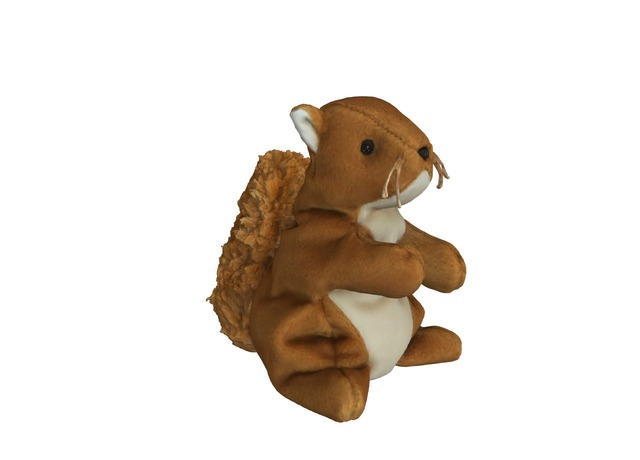

--- Lancement de l'inférence ---
Fichier : preview/Squirrel/Squirrel.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:19:59.050819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778404799.075401    4372 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778404799.083194    4372 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778404799.103347    4372 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778404799.103399    4372 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid li

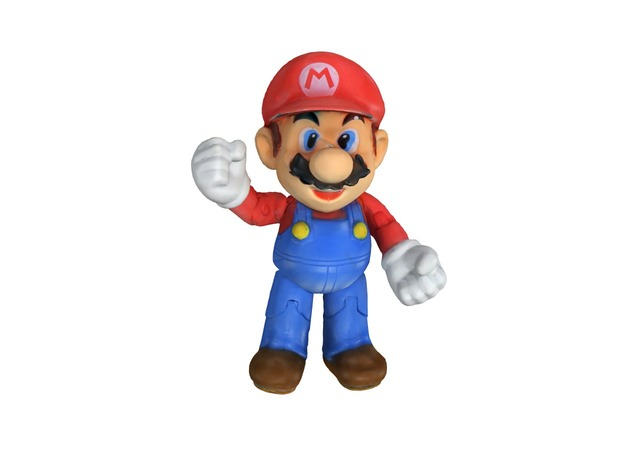

--- Lancement de l'inférence ---
Fichier : preview/Nintendo_Mario_Action_Figure/Nintendo_Mario_Action_Figure.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:24:07.113843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405047.137421    4517 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405047.145341    4517 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405047.166876    4517 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405047.166925    4517 computation_placer.cc:177] computation placer already regis

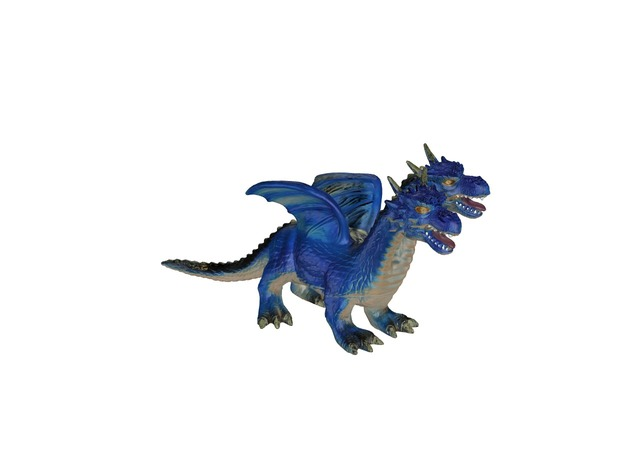

--- Lancement de l'inférence ---
Fichier : preview/Animal_Planet_Foam_2Headed_Dragon/Animal_Planet_Foam_2Headed_Dragon.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:28:02.673351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405282.699023    4662 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405282.707275    4662 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405282.728964    4662 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405282.729000    4662 computation_placer.cc:177] computation placer alr

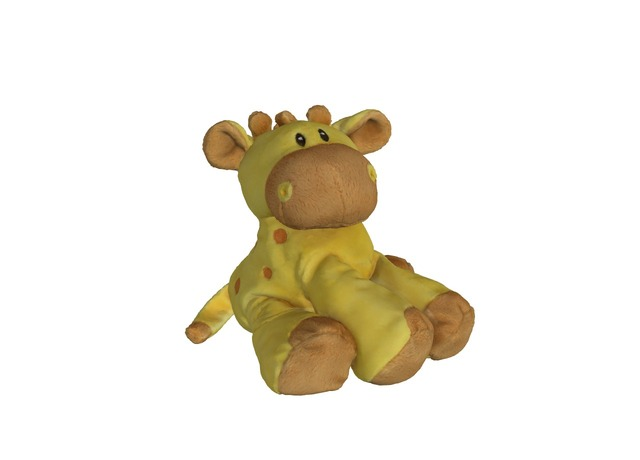

--- Lancement de l'inférence ---
Fichier : preview/Ortho_Forward_Facing/Ortho_Forward_Facing.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:31:56.090879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405516.114859    4807 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405516.122851    4807 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405516.143654    4807 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405516.143683    4807 computation_placer.cc:177] computation placer already registered. Please ch

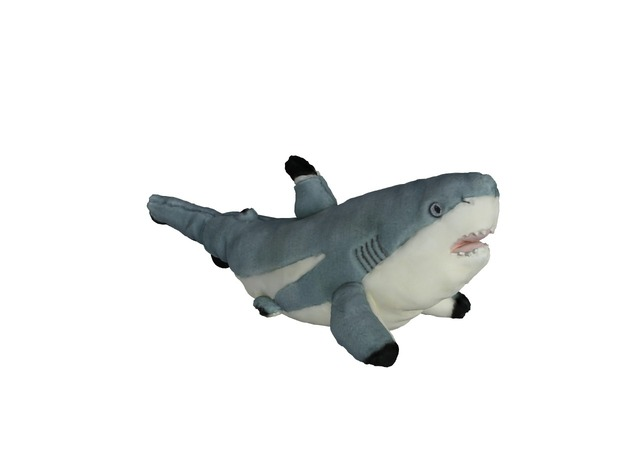

--- Lancement de l'inférence ---
Fichier : preview/Shark/Shark.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:35:42.702364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405742.725765    4952 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405742.733726    4952 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405742.754444    4952 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405742.754470    4952 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

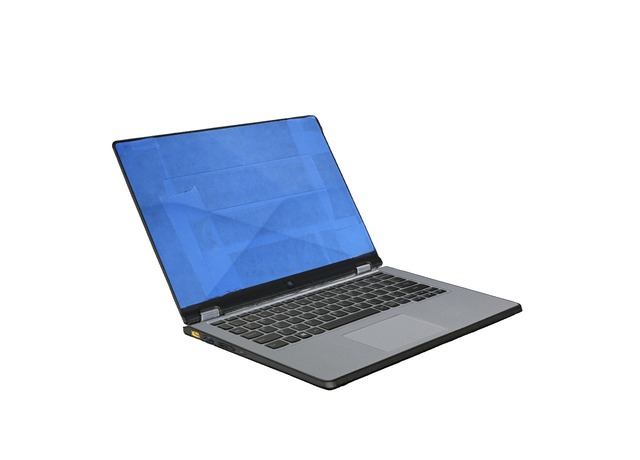

--- Lancement de l'inférence ---
Fichier : preview/Lenovo_Yoga_2_11/Lenovo_Yoga_2_11.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:39:27.647511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778405967.670884    5097 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778405967.678651    5097 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778405967.700312    5097 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778405967.700341    5097 computation_placer.cc:177] computation placer already registered. Please check link

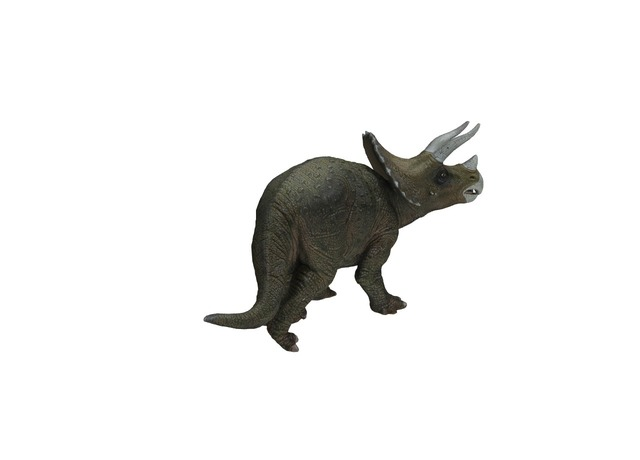

--- Lancement de l'inférence ---
Fichier : preview/Dino_5/Dino_5.jpg
Modèle : zero123plus_finetuned
/content/InstantMesh
2026-05-10 09:43:13.646982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778406193.670589    5242 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778406193.678415    5242 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778406193.699164    5242 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778406193.699194    5242 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [66]:
import os
from IPython.display import Image as DisplayImage, display
from zipfile import ZipFile

source_folder = "/kaggle/working/Google_data"
temp_preview_dir = "preview"

zip_files = [f for f in os.listdir(source_folder) if f.endswith('.zip')]

if zip_files:
    for zip_name in zip_files:
        target_zip = os.path.join(source_folder, zip_name)
        zip_id = os.path.splitext(zip_name)[0]
        
        print(f"Processing: {zip_name}")

        with ZipFile(target_zip, 'r') as z:
            images = sorted([f for f in z.namelist() if "thumbnails" in f.lower() and f.lower().endswith(('.jpg', '.png'))])
            
            if not images:
                images = sorted([f for f in z.namelist() if f.lower().endswith(('.jpg', '.png')) and "texture" not in f.lower()])
            
            if not images:
                print(f"No valid image found in {zip_name}")
                continue
            
            first_image = images[0]
            extraction_path = os.path.join(temp_preview_dir, zip_id)
            z.extract(first_image, extraction_path)
            
            full_img_path = os.path.join(extraction_path, first_image)
            unique_img_path = os.path.join(extraction_path, f"{zip_id}.jpg")
            
            os.rename(full_img_path, unique_img_path)
            
            display(DisplayImage(filename=unique_img_path, width=200))
            
            executer_inference_3d(filename=unique_img_path, model_type="zero123plus_finetuned")
            
            
            chemin_complet = os.path.abspath(unique_img_path)
            executer_inference_3d(filename=chemin_complet, model_type="syncdreamer")
            


    # !rm -rf preview
else:
    print(f"No ZIP files found in {source_folder}")

In [67]:
import os
import numpy as np
import trimesh
from zipfile import ZipFile

def extract_points(obj):
    """Extrait les points de n'importe quel format d'objet 3D."""
    if isinstance(obj, trimesh.Scene):
        if len(obj.geometry) == 0: return None
        points = np.concatenate([m.vertices for m in obj.geometry.values() if hasattr(m, 'vertices')])
    else:
        points = obj.vertices
    
    if points is None or len(points) == 0: return None
    

    points = points - np.mean(points, axis=0)
    dist = np.linalg.norm(points, axis=1)
    scale = np.max(dist)
    if scale > 0: points /= scale
    return points

def chamfer_numpy_pure(p1, p2):
    """Distance de Chamfer en NumPy pur (lent mais fiable)."""

    
    def get_nn_dist(pts_src, pts_tgt):
        total_dist = 0
        chunk_size = 500 
        for i in range(0, len(pts_src), chunk_size):
            chunk = pts_src[i:i+chunk_size]

            diff = chunk[:, np.newaxis, :] - pts_tgt[np.newaxis, :, :]
            dist_sq = np.sum(diff**2, axis=2)
            total_dist += np.sum(np.min(dist_sq, axis=1))
        return total_dist / len(pts_src)

    return get_nn_dist(p1, p2) + get_nn_dist(p2, p1)

SOURCE_ZIP = "/kaggle/working/Google_data" 
OUTPUT_BASE = "/content/InstantMesh/outputs"
modeles = {"Fine-tuned": "instant-mesh-base_zero123plus_finetuned", "SyncDreamer": "instant-mesh-base_syncdreamer"}

fichiers_zip = [f for f in os.listdir(SOURCE_ZIP) if f.endswith('.zip')] if os.path.exists(SOURCE_ZIP) else []

print(f"{'Objet':<35} | {'Fine-tuned':<18} | {'SyncDreamer':<18}")
print("-" * 80)

scores_globaux = {k: [] for k in modeles.keys()}

for fichier in fichiers_zip:
    id_obj = fichier.replace('.zip', '')
    ligne = f"{id_obj[:33]:<35}"
    
    try:

        with ZipFile(os.path.join(SOURCE_ZIP, fichier), 'r') as z:
            objs = [f for f in z.namelist() if f.lower().endswith('.obj')]
            if not objs: continue
            p_orig = extract_points(trimesh.load(z.extract(objs[0], path="/tmp/eval")))

        for label, folder in modeles.items():
            path_gen = os.path.join(OUTPUT_BASE, folder, "meshes", f"{id_obj}.obj")
            if os.path.exists(path_gen):
                try:
                    p_gen = extract_points(trimesh.load(path_gen))
                    if p_gen is not None:
                        p_gen_sub = p_gen[::max(1, len(p_gen)//1000)]
                        p_orig_sub = p_orig[::max(1, len(p_orig)//1000)]
                        
                        val = chamfer_numpy_pure(p_gen_sub, p_orig_sub)
                        ligne += f" | {val:<18.6f}"
                        scores_globaux[label].append(val)
                    else: ligne += f" | {'Empty Mesh':<18}"
                except Exception: ligne += f" | {'Calc Error':<18}"
            else: ligne += f" | {'Not Found':<18}"
        print(ligne)
    except: print(f"{id_obj:<35} | ZIP/Loading Error")

print("-" * 80)
print(f"{'MOYENNE':<35} | {np.mean(scores_globaux['Fine-tuned']) if scores_globaux['Fine-tuned'] else 'N/A':<18} | {np.mean(scores_globaux['SyncDreamer']) if scores_globaux['SyncDreamer'] else 'N/A'}")

Objet                               | Fine-tuned         | SyncDreamer       
--------------------------------------------------------------------------------
Squirrel                            | 0.096300           | 0.056055          
Nintendo_Mario_Action_Figure        | 0.034221           | 0.037402          
Animal_Planet_Foam_2Headed_Dragon   | 0.051330           | 0.066003          
Ortho_Forward_Facing                | 0.083234           | 0.108860          
Shark                               | 0.077485           | 0.123710          
Lenovo_Yoga_2_11                    | 0.103845           | 0.079211          
Dino_5                              | 0.094794           | 0.092902          
--------------------------------------------------------------------------------
MOYENNE                             | 0.07731554506457906 | 0.08059208692381938


In [63]:
import shutil
import os

path = '/kaggle/working/Google_data'

if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Le dossier {path} a été supprimé.")
else:
    print("Le dossier n'existe pas.")

Le dossier /kaggle/working/Google_data a été supprimé.
